In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from matplotlib.colors import ListedColormap

from functions import *

In [15]:
with open('synch_analysis_aut_testDIST.pickle', 'rb') as file:
    df_aut = pickle.load(file)

with open('synch_analysis_naut_testDIST.pickle', 'rb') as file:
    df_naut = pickle.load(file)

print(df_aut.keys())

df_aut['I_inj'] = df_aut['I_inj'].round(0)
df_aut['w_e1_e2'] = df_aut['w_e1_e2'].round(0)
df_aut['w_e2_e1'] = df_aut['w_e2_e1'].round(0)

df_naut['I_inj'] = df_naut['I_inj'].round(0)
df_naut['w_e1_e2'] = df_naut['w_e1_e2'].round(0)
df_naut['w_e2_e1'] = df_naut['w_e2_e1'].round(0)


#Create a difference dataframe
diff_df = df_aut.copy()
diff_df['FT_distance'] = df_aut['FT_distance'] - df_naut['FT_distance']
diff_df['FT_EMD'] = df_aut['FT_EMD'] - df_naut['FT_EMD']
diff_df['ISI_distance'] = df_aut['ISI_distance'] - df_naut['ISI_distance']
diff_df['SPIKE_distance'] = df_aut['SPIKE_distance'] - df_naut['SPIKE_distance']
diff_df['SPIKE_synchrony'] = df_aut['SPIKE_synchrony'] - df_naut['SPIKE_synchrony']
diff_df['spike_directionality'] = df_aut['spike_directionality'] - df_naut['spike_directionality']

print(df_aut['I_inj'].unique())
print(df_naut['w_e1_e2'].unique())
print(df_aut['w_e2_e1'].unique())

''' NEED TO PICK THE FIXED VALUES '''
FIXED_VALUES = [64, 64, 204]

Index(['I_inj', 'w_e1_e2', 'w_e2_e1', 'FT_distance', 'FT_EMD', 'ISI_distance',
       'SPIKE_distance', 'SPIKE_synchrony', 'spike_directionality'],
      dtype='object')
[120. 128. 137. 145. 154. 162. 171. 179. 187. 196. 204. 213. 221. 229.
 238. 246. 255. 263. 272. 280.]
[ 20.  29.  38.  47.  56.  64.  73.  82.  91. 100.]
[ 20.  29.  38.  47.  56.  64.  73.  82.  91. 100.]


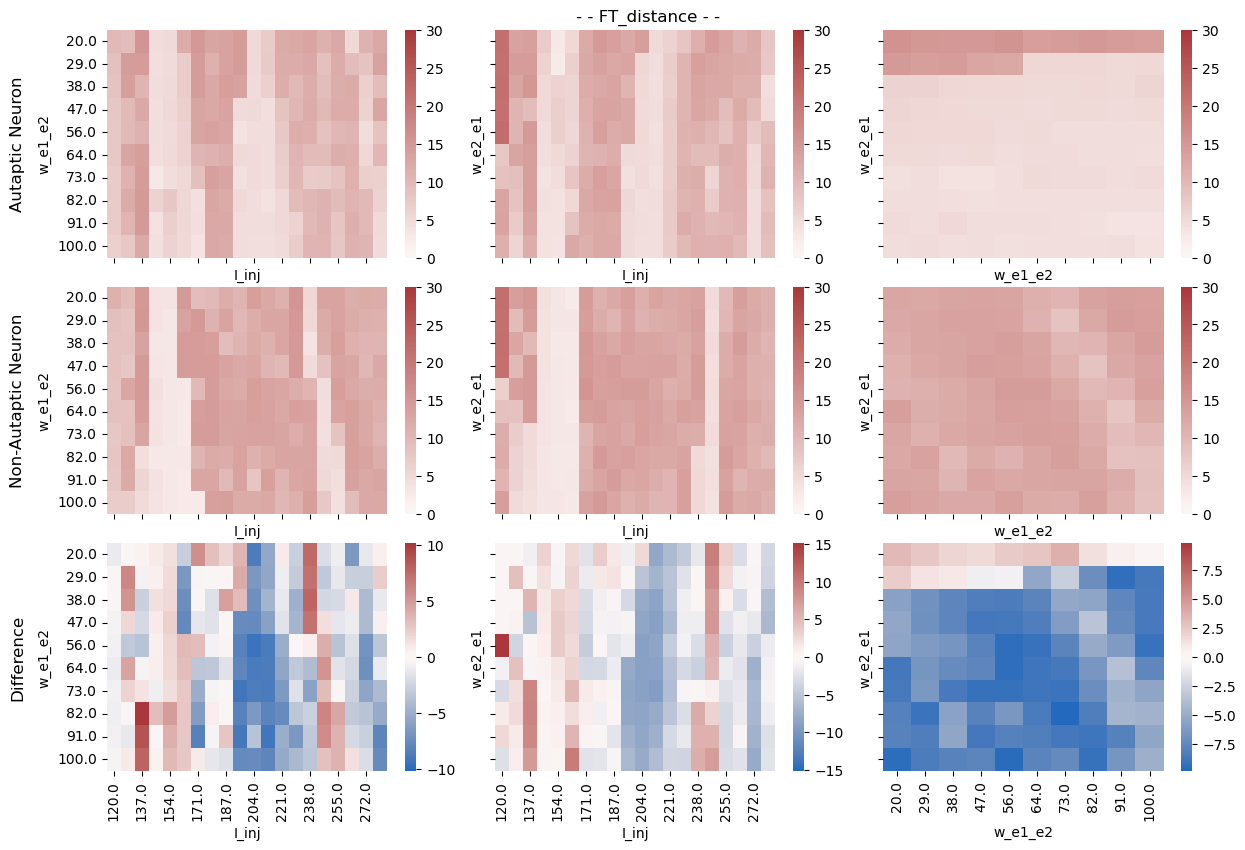

In [19]:
'''- - PLOT FT DISTANCE - -'''
# each row will be a different set of inputs
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'FT_distance', fixed_values = FIXED_VALUES, v_min = 0, v_max = 30)


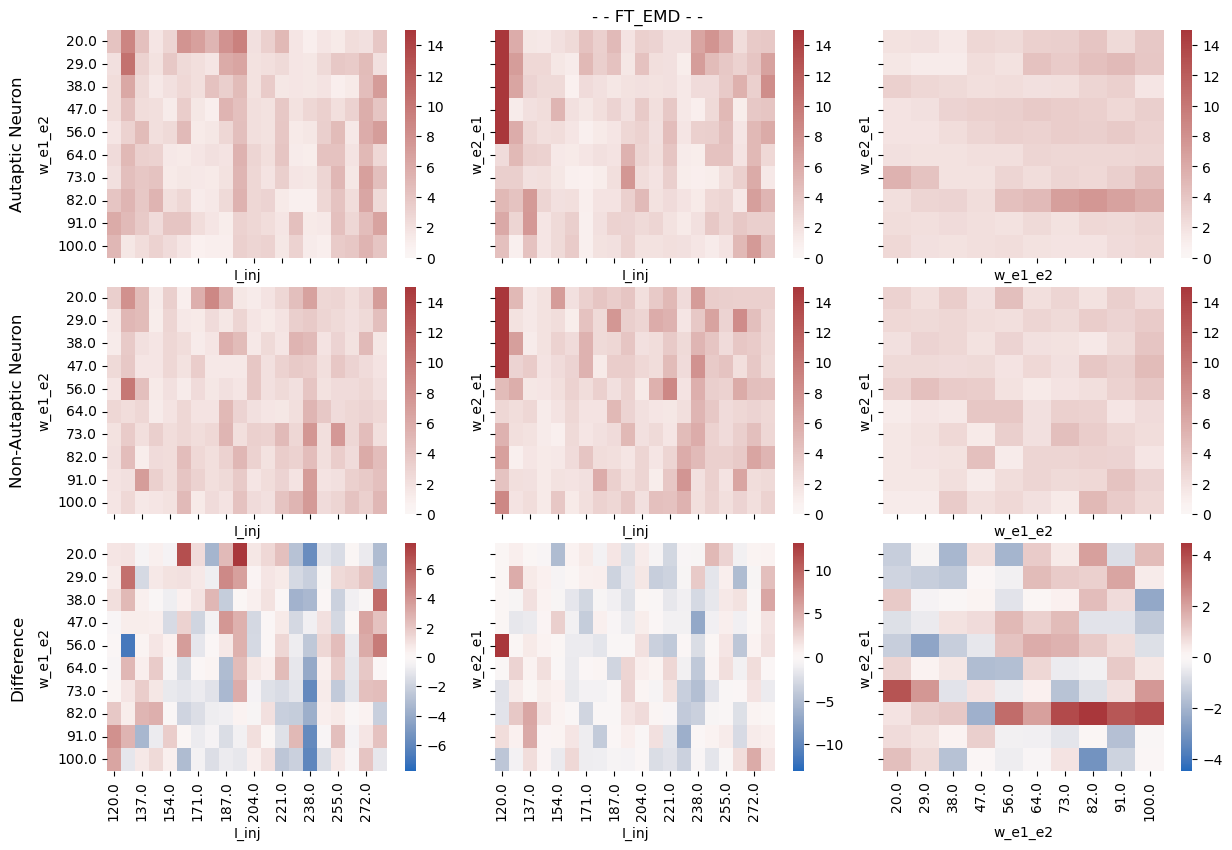

In [20]:
'''- - PLOT FT Earth mover's distance - -'''
# each row will be a different set of inputs
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'FT_EMD', fixed_values = FIXED_VALUES, v_min = 0, v_max = 15)


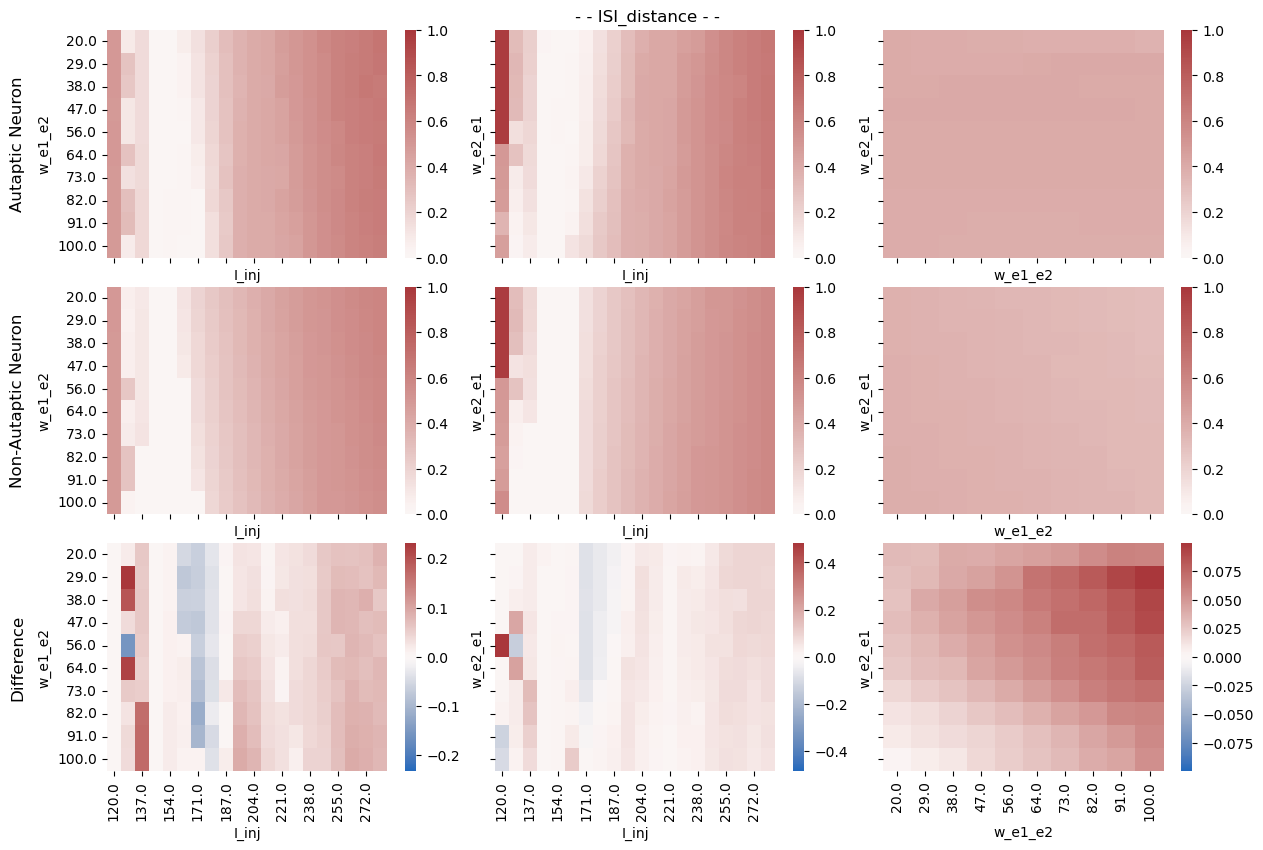

In [5]:
'''- - PLOT ISI DISTANCE - -'''
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'ISI_distance', fixed_values = FIXED_VALUES, v_min = 0, v_max = 1)

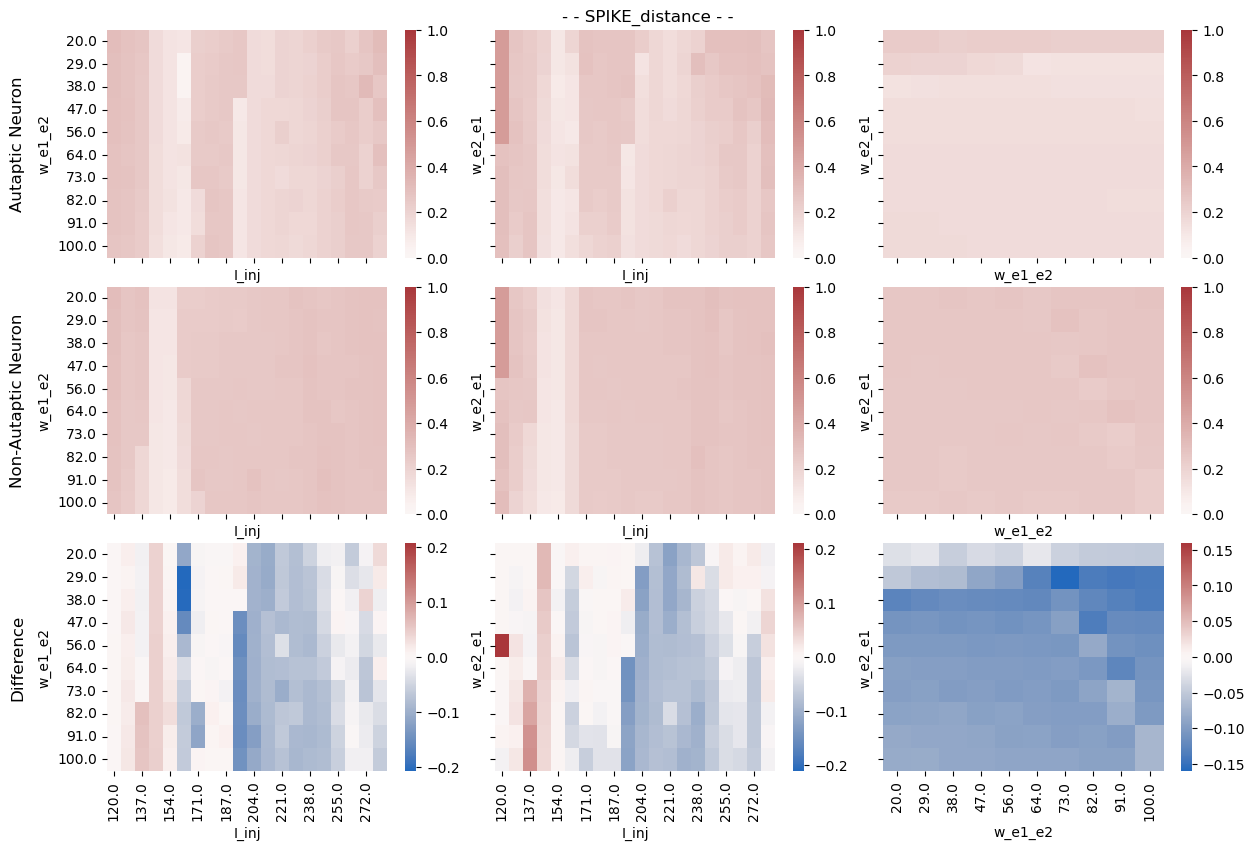

In [6]:
'''- - PLOT SPIKE DISTANCE - -'''
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'SPIKE_distance', fixed_values = FIXED_VALUES, v_min = 0, v_max = 1)

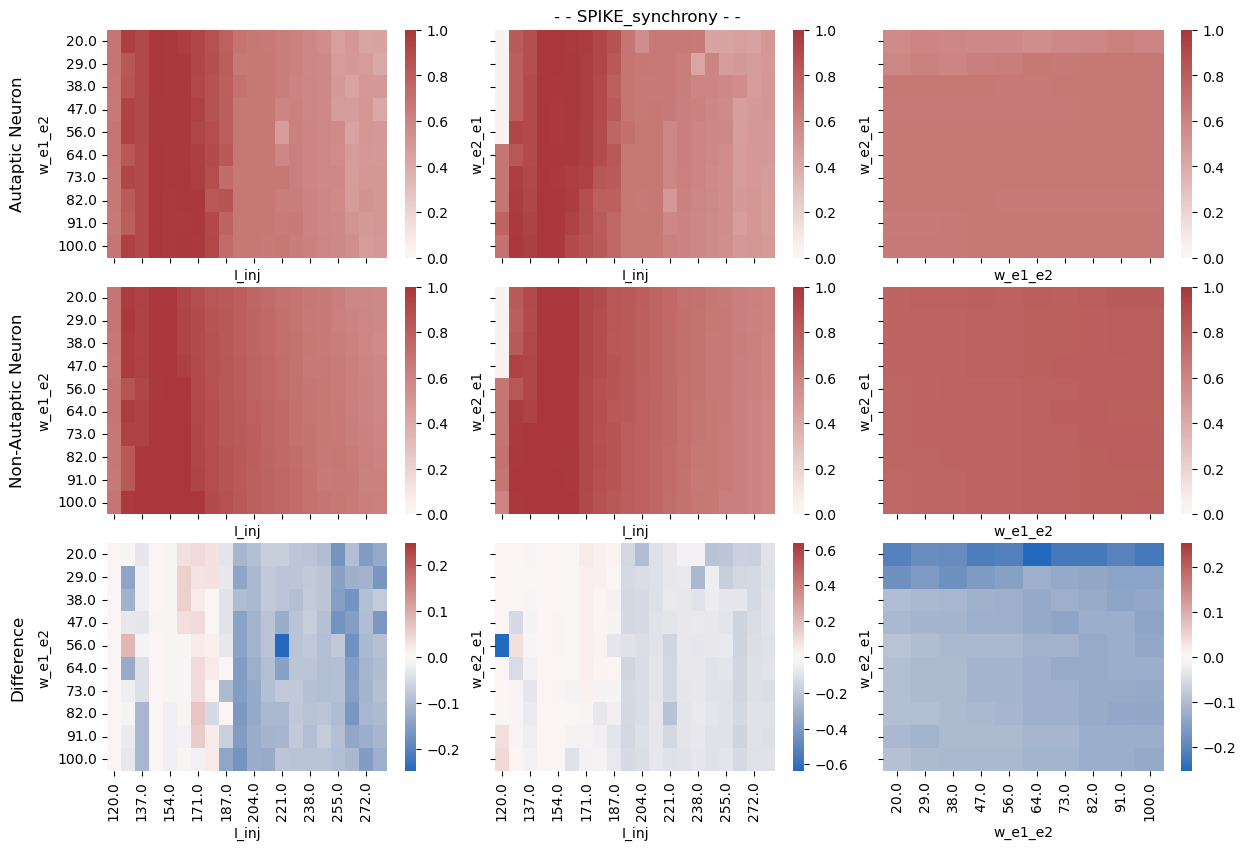

In [7]:
'''- - PLOT SPIKE SYNCHRONY - -'''
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'SPIKE_synchrony', fixed_values = FIXED_VALUES, v_min = 0, v_max = 1)

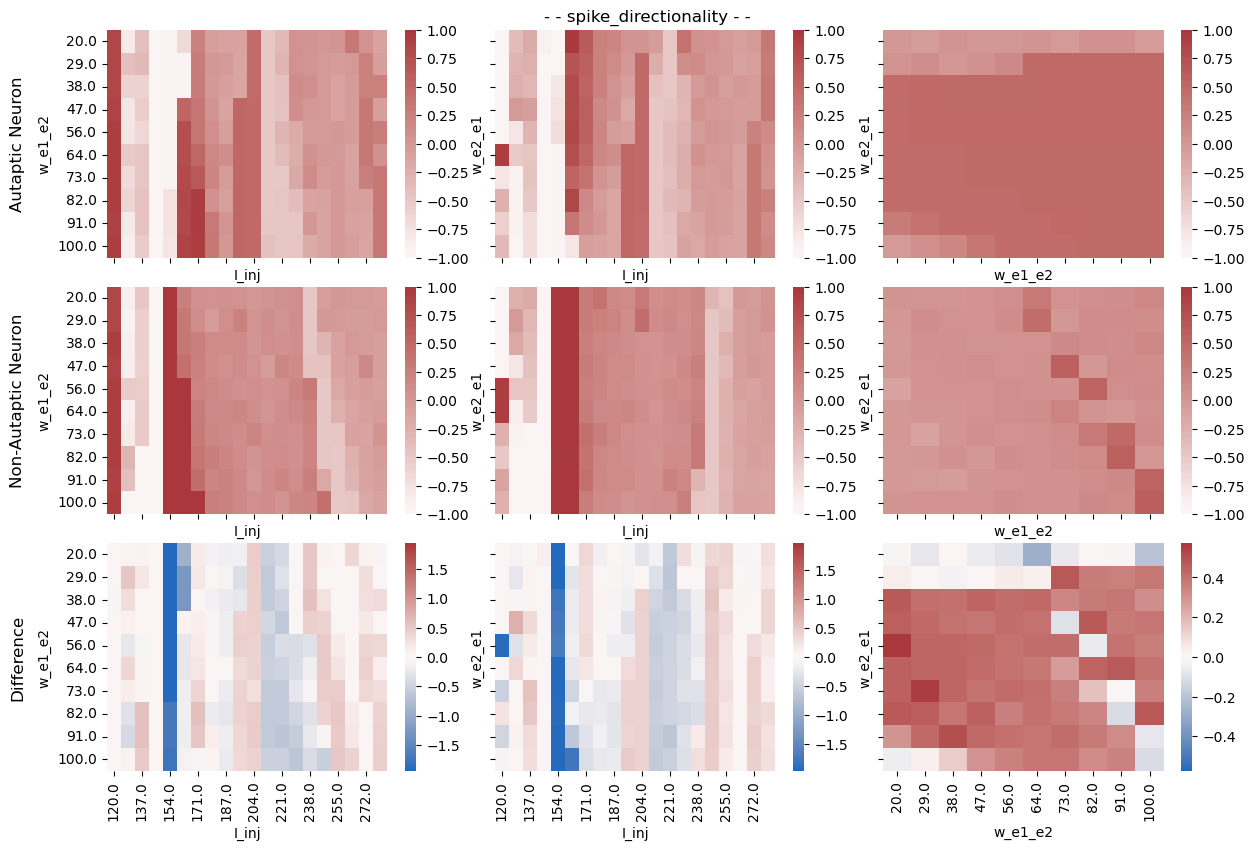

In [8]:
'''- - PLOT SPIKE DIRECTIONALITY (<0 means E1 leads) - -'''
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'spike_directionality', fixed_values = FIXED_VALUES, v_min = -1, v_max = 1)